In [1]:
import math
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.ndimage import rotate
from scipy.ndimage import maximum_filter
from scipy.signal import convolve2d

from typing import List, Sequence, Tuple

In [2]:
# --------------------------------------------------
# Data
# --------------------------------------------------

LAYER_NAME = "d4"

TRAJECTORY_RESULTS_PATH = (
    r"C:\Users\ALL AtoZ\Desktop\2d_hippocampal_cells\2D-traj-results-training.pkl"
)

# --------------------------------------------------
# Analysis
# --------------------------------------------------

N_BINS = 40

GAUSSIAN_WINDOW = 9

GAUSSIAN_SIGMA = 3.0

THRESHOLD_K = 1.5

EPS = 1e-10

SKIP_TIMESTEPS = 50

BOUNDS = (0.0, 1.0, 0.0, 1.0)

In [3]:
def matlab_style_gauss2d(shape=(9,9), sigma=3.0):

    m, n = [(ss-1.)/2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x+y*y)/(2*sigma*sigma))

    h[h < np.finfo(h.dtype).eps*h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h

In [4]:
def occupancy_map_func(
    pos,
    reso=N_BINS//2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
):

    hist, _, _ = np.histogram2d(
        pos[:,0],
        pos[:,1],
        bins=reso*2,
    )

    gaussian = matlab_style_gauss2d(
        (win_len,win_len),
        sigma,
    )

    pos_prob = signal.convolve2d(
        gaussian,
        hist,
    )

    trim = win_len//2

    pos_prob = pos_prob[
        trim:-trim,
        trim:-trim,
    ]

    pos_prob /= np.nansum(pos_prob)

    return pos_prob

In [5]:
def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = N_BINS,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:

    mean_resp = np.mean(responses)
    std_resp = np.std(responses)

    thresh = mean_resp + (thresh_param * std_resp)

    firing_idx = np.flatnonzero(
        responses > thresh
    )

    xmin, xmax = (
        float(np.min(pos[:, 0])),
        float(np.max(pos[:, 0]))
    )

    ymin, ymax = (
        float(np.min(pos[:, 1])),
        float(np.max(pos[:, 1]))
    )

    x = np.linspace(
        xmin,
        xmax,
        res_param
    )

    y = np.linspace(
        ymin,
        ymax,
        res_param
    )

    firing_map = np.zeros(
        (res_param, res_param),
        dtype=float
    )

    if firing_idx.size:

        firing_positions = pos[
            firing_idx,
            :2
        ]

        firing_values = responses[
            firing_idx
        ]

        for ii in range(
            len(firing_positions)
        ):

            col = int(
                np.argmin(
                    np.abs(
                        firing_positions[ii, 0] - x
                    )
                )
            )

            row = int(
                np.argmin(
                    np.abs(
                        firing_positions[ii, 1] - y
                    )
                )
            )

            firing_map[row, col] = max(
                firing_values[ii],
                firing_map[row, col]
            )

    if (
        normalization == "occupancy"
        and occupancy_map is not None
    ):

        occ = np.asarray(
            occupancy_map,
            dtype=float
        ).copy()

        occ[occ == 0] = np.nan

        with np.errstate(
            divide="ignore",
            invalid="ignore"
        ):

            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(
                    firing_map,
                    dtype=float
                ),
                where=(
                    np.isfinite(occ)
                    & (occ != 0)
                ),
            )

        firing_map = np.nan_to_num(
            firing_map,
            nan=0.0
        )

    else:

        max_value = (
            float(np.nanmax(firing_map))
            if firing_map.size
            else 0.0
        )

        if max_value > 0:

            firing_map = (
                firing_map / max_value
            )

    gaussian = matlab_style_gauss2d(
        gaussian_shape,
        gaussian_sigma
    )

    spikes_smooth = signal.convolve2d(
        gaussian,
        firing_map
    )

    trim = int(
        gaussian_shape[0] // 2
    )

    spikes_smooth = spikes_smooth[
        trim:-trim,
        trim:-trim
    ]

    extent = [
        xmin,
        xmax,
        ymin,
        ymax
    ]

    return (
        spikes_smooth,
        extent
    )

In [6]:
def load_dataset(
    pkl_path,
    layer_name,
    skip_timesteps=SKIP_TIMESTEPS,
):
    """
    Load trajectory predictions and neural activations.

    Returns
    -------
    ground_truth : (n_traj, T, 2)
    prediction   : (n_traj, T, 2)
    positions    : (n_traj, T, 2)
    activations  : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(
        data["ground_truth"]
    )

    prediction = np.asarray(
        data["prediction"]
    )

    activations = np.asarray(
        data[layer_name]
    )

    # We analyse predicted positions
    positions = prediction.copy()

    if skip_timesteps > 0:

        ground_truth = (
            ground_truth[:, skip_timesteps:, :]
        )

        prediction = (
            prediction[:, skip_timesteps:, :]
        )

        positions = (
            positions[:, skip_timesteps:, :]
        )

        activations = (
            activations[:, skip_timesteps:, :]
        )

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [7]:
def concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    trajectory_ids,
):
    """
    Concatenate multiple trajectories into one long trajectory.
    """

    return {

        "positions": np.concatenate(
            [positions[i] for i in trajectory_ids],
            axis=0,
        ),

        "activations": np.concatenate(
            [activations[i] for i in trajectory_ids],
            axis=0,
        ),

        "ground_truth": np.concatenate(
            [ground_truth[i] for i in trajectory_ids],
            axis=0,
        ),

        "prediction": np.concatenate(
            [prediction[i] for i in trajectory_ids],
            axis=0,
        ),
    }

In [8]:
EPS = 1e-10

def spatial_information(
    rate_map,
    occupancy_map,
):
    """
    Spatial Information (Skaggs et al., 1993)

    Parameters
    ----------
    rate_map : (N,N)
        Smoothed firing-rate map

    occupancy_map : (N,N)
        Probability occupancy map (sum = 1)

    Returns
    -------
    Spatial Information (bits/spike)
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
        &
        (rate_map > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    if mean_rate < EPS:
        return np.nan

    ratio = r / mean_rate

    SI = np.sum(
        p *
        ratio *
        np.log2(ratio)
    )

    return SI

In [9]:
def sparsity(
    rate_map,
    occupancy_map,
):
    """
    Population Sparsity
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    mean_rate_sq = np.sum(
        p * r**2
    )

    if mean_rate_sq < EPS:
        return np.nan

    return (mean_rate**2) / mean_rate_sq

In [10]:
ground_truth, prediction, positions, activations = load_dataset(
    TRAJECTORY_RESULTS_PATH,
    LAYER_NAME,
)

print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [11]:
# ============================================================
# PLACE CELL ANALYSIS — RESET
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ------------------------------------------------------------
# Spatial resolution
# ------------------------------------------------------------

N_BINS = 40

# Environment boundaries
X_MIN, X_MAX = 0.0, 1.0
Y_MIN, Y_MAX = 0.0, 1.0

BOUNDS = (
    X_MIN,
    X_MAX,
    Y_MIN,
    Y_MAX,
)

# ------------------------------------------------------------
# Spatial bin edges
# ------------------------------------------------------------

x_edges = np.linspace(
    X_MIN,
    X_MAX,
    N_BINS + 1
)

y_edges = np.linspace(
    Y_MIN,
    Y_MAX,
    N_BINS + 1
)

# ------------------------------------------------------------
# Reference environment
# ------------------------------------------------------------
# A spatial bin belongs to the environment if it is visited
# by at least one trajectory.

environment_counts, _, _ = np.histogram2d(
    positions[:, :, 0].ravel(),
    positions[:, :, 1].ravel(),
    bins=[x_edges, y_edges]
)

environment_mask = (
    environment_counts > 0
)

n_environment_bins = (
    environment_mask.sum()
)

# ------------------------------------------------------------
# Firing-rate parameters
# ------------------------------------------------------------

THRESHOLD_K = 1.5

GAUSSIAN_WINDOW = 9
GAUSSIAN_SIGMA = 3.0

EPS = 1e-10

# ------------------------------------------------------------
# Check data
# ------------------------------------------------------------

print(
    "Ground truth :",
    ground_truth.shape
)

print(
    "Prediction   :",
    prediction.shape
)

print(
    "Positions    :",
    positions.shape
)

print(
    "Activations  :",
    activations.shape
)

print(
    "\nN_BINS:",
    N_BINS
)

print(
    "Bounds:",
    BOUNDS
)

print(
    "Environment bins:",
    n_environment_bins
)

Ground truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)

N_BINS: 40
Bounds: (0.0, 1.0, 0.0, 1.0)
Environment bins: 1381


In [12]:
# ============================================================
# RANDOM SAMPLING CONVERGENCE
# ============================================================

N_RANDOM_TRIALS = 100
MAX_TRAJECTORIES = 10

rng = np.random.default_rng(42)

coverage_all = np.zeros(
    (N_RANDOM_TRIALS, MAX_TRAJECTORIES)
)

for trial in range(N_RANDOM_TRIALS):

    # Randomly choose 10 unique trajectories
    random_traj = rng.choice(
        len(positions),
        size=MAX_TRAJECTORIES,
        replace=False
    )

    cumulative_mask = np.zeros(
        (N_BINS, N_BINS),
        dtype=bool
    )

    for n in range(MAX_TRAJECTORIES):

        traj_id = random_traj[n]
        traj = positions[traj_id]

        traj_counts, _, _ = np.histogram2d(
            traj[:, 0],
            traj[:, 1],
            bins=[x_edges, y_edges]
        )

        # Add trajectory's visited bins
        cumulative_mask |= (
            traj_counts > 0
        )

        # Compare against reference environment
        covered = (
            cumulative_mask
            &
            environment_mask
        )

        coverage_all[
            trial,
            n
        ] = (
            covered.sum()
            / n_environment_bins
        )


# ============================================================
# Calculate statistics
# ============================================================

mean_coverage = coverage_all.mean(
    axis=0
)

std_coverage = coverage_all.std(
    axis=0
)

lower_coverage = np.percentile(
    coverage_all,
    2.5,
    axis=0
)

upper_coverage = np.percentile(
    coverage_all,
    97.5,
    axis=0
)


# ============================================================
# Print results
# ============================================================

print("Random sampling convergence")
print("=" * 45)

for n in range(MAX_TRAJECTORIES):

    print(
        f"{n+1:2d} trajectories | "
        f"mean = "
        f"{mean_coverage[n] * 100:6.2f}% | "
        f"SD = "
        f"{std_coverage[n] * 100:5.2f}% | "
        f"95% CI = "
        f"{lower_coverage[n] * 100:5.2f}%–"
        f"{upper_coverage[n] * 100:5.2f}%"
    )

Random sampling convergence
 1 trajectories | mean =   9.67% | SD =  3.13% | 95% CI =  4.33%–14.30%
 2 trajectories | mean =  17.92% | SD =  3.59% | 95% CI = 10.34%–24.55%
 3 trajectories | mean =  26.04% | SD =  4.07% | 95% CI = 17.53%–33.43%
 4 trajectories | mean =  32.85% | SD =  4.44% | 95% CI = 23.41%–40.15%
 5 trajectories | mean =  39.06% | SD =  4.72% | 95% CI = 30.14%–47.11%
 6 trajectories | mean =  44.51% | SD =  4.54% | 95% CI = 35.07%–51.32%
 7 trajectories | mean =  48.73% | SD =  4.59% | 95% CI = 39.89%–56.48%
 8 trajectories | mean =  52.58% | SD =  4.70% | 95% CI = 43.87%–60.25%
 9 trajectories | mean =  56.07% | SD =  4.39% | 95% CI = 47.28%–62.65%
10 trajectories | mean =  59.35% | SD =  4.09% | 95% CI = 51.37%–65.76%


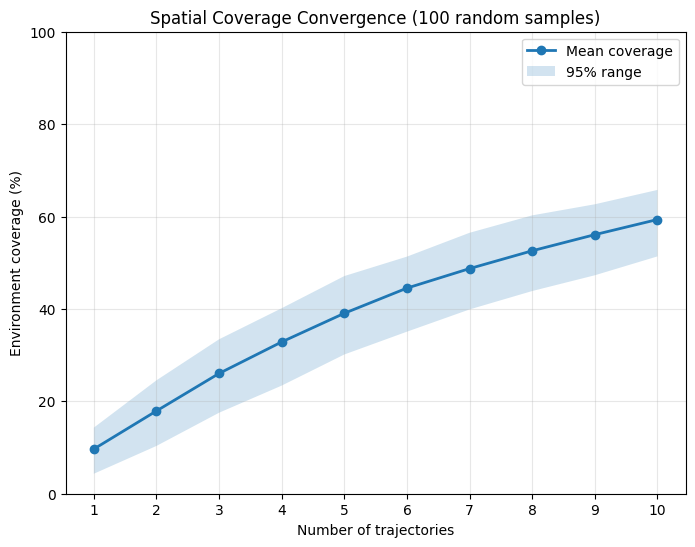

In [13]:
# ============================================================
# CONVERGENCE PLOT
# ============================================================

x = np.arange(
    1,
    MAX_TRAJECTORIES + 1
)

plt.figure(figsize=(8, 6))

plt.plot(
    x,
    mean_coverage * 100,
    marker="o",
    linewidth=2,
    label="Mean coverage"
)

plt.fill_between(
    x,
    lower_coverage * 100,
    upper_coverage * 100,
    alpha=0.2,
    label="95% range"
)

plt.xlabel(
    "Number of trajectories"
)

plt.ylabel(
    "Environment coverage (%)"
)

plt.title(
    f"Spatial Coverage Convergence "
    f"({N_RANDOM_TRIALS} random samples)"
)

plt.xticks(x)

plt.ylim(0, 100)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [14]:
# ============================================================
# GREEDY SELECTION OF 10 TRAJECTORIES FOR MAXIMUM COVERAGE
# ============================================================

N_SELECT = 10

# ------------------------------------------------------------
# 1. Precompute spatial-bin mask for every trajectory
# ------------------------------------------------------------

trajectory_masks = []

for traj_id in range(len(positions)):

    traj = positions[traj_id]

    counts, _, _ = np.histogram2d(
        traj[:, 0],
        traj[:, 1],
        bins=[x_edges, y_edges]
    )

    trajectory_masks.append(
        counts > 0
    )

trajectory_masks = np.array(
    trajectory_masks
)

print(
    "Trajectory masks:",
    trajectory_masks.shape
)


# ------------------------------------------------------------
# 2. Greedy selection
# ------------------------------------------------------------

selected_traj = []

cumulative_mask = np.zeros(
    (N_BINS, N_BINS),
    dtype=bool
)

coverage_values = []

remaining = set(
    range(len(positions))
)

for step in range(N_SELECT):

    best_traj = None
    best_new_bins = -1

    # Find trajectory adding the most
    # previously uncovered bins
    for traj_id in remaining:

        candidate_mask = (
            trajectory_masks[traj_id]
        )

        new_bins = (
            candidate_mask
            &
            environment_mask
            &
            ~cumulative_mask
        ).sum()

        if new_bins > best_new_bins:

            best_new_bins = new_bins
            best_traj = traj_id

    # Add best trajectory
    selected_traj.append(
        best_traj
    )

    cumulative_mask |= (
        trajectory_masks[best_traj]
    )

    remaining.remove(
        best_traj
    )

    # Calculate coverage
    covered = (
        cumulative_mask
        &
        environment_mask
    )

    coverage = (
        covered.sum()
        /
        n_environment_bins
    )

    coverage_values.append(
        coverage
    )

    print(
        f"{step + 1:2d} trajectories | "
        f"added trajectory "
        f"{best_traj:3d} | "
        f"new bins = "
        f"{best_new_bins:4d} | "
        f"coverage = "
        f"{coverage * 100:6.2f}%"
    )


# ------------------------------------------------------------
# 3. Final result
# ------------------------------------------------------------

print(
    "\n========================================"
)

print(
    "FINAL SELECTED TRAJECTORIES"
)

print(
    "========================================"
)

print(
    selected_traj
)

print(
    f"\nFinal coverage: "
    f"{coverage_values[-1] * 100:.2f}%"
)

Trajectory masks: (500, 40, 40)
 1 trajectories | added trajectory 342 | new bins =  216 | coverage =  15.64%
 2 trajectories | added trajectory 397 | new bins =  181 | coverage =  28.75%
 3 trajectories | added trajectory  56 | new bins =  145 | coverage =  39.25%
 4 trajectories | added trajectory 234 | new bins =  128 | coverage =  48.52%
 5 trajectories | added trajectory 220 | new bins =  112 | coverage =  56.63%
 6 trajectories | added trajectory  30 | new bins =   95 | coverage =  63.50%
 7 trajectories | added trajectory 343 | new bins =   72 | coverage =  68.72%
 8 trajectories | added trajectory 456 | new bins =   63 | coverage =  73.28%
 9 trajectories | added trajectory 201 | new bins =   48 | coverage =  76.76%
10 trajectories | added trajectory 378 | new bins =   43 | coverage =  79.87%

FINAL SELECTED TRAJECTORIES
[342, 397, 56, 234, 220, 30, 343, 456, 201, 378]

Final coverage: 79.87%


In [15]:
# ============================================================
# FROZEN TRAJECTORIES — DO NOT CHANGE BELOW THIS CELL
# ============================================================

selected_traj = [
    342,
    397,
    56,
    234,
    220,
    30,
    343,
    456,
    201,
    378
]

N_TRAJECTORIES = len(selected_traj)
N_NEURONS = activations.shape[2]

print("Frozen trajectories:")
print(selected_traj)

print("\nNumber of trajectories:", N_TRAJECTORIES)
print("Number of neurons:", N_NEURONS)

# Safety check
assert len(selected_traj) == 10
assert len(set(selected_traj)) == 10
assert min(selected_traj) >= 0
assert max(selected_traj) < len(positions)

print("\n✓ Trajectories successfully frozen.")

Frozen trajectories:
[342, 397, 56, 234, 220, 30, 343, 456, 201, 378]

Number of trajectories: 10
Number of neurons: 100

✓ Trajectories successfully frozen.


Frozen trajectories:
[342, 397, 56, 234, 220, 30, 343, 456, 201, 378]

Combined trajectory shape: (4500, 2)


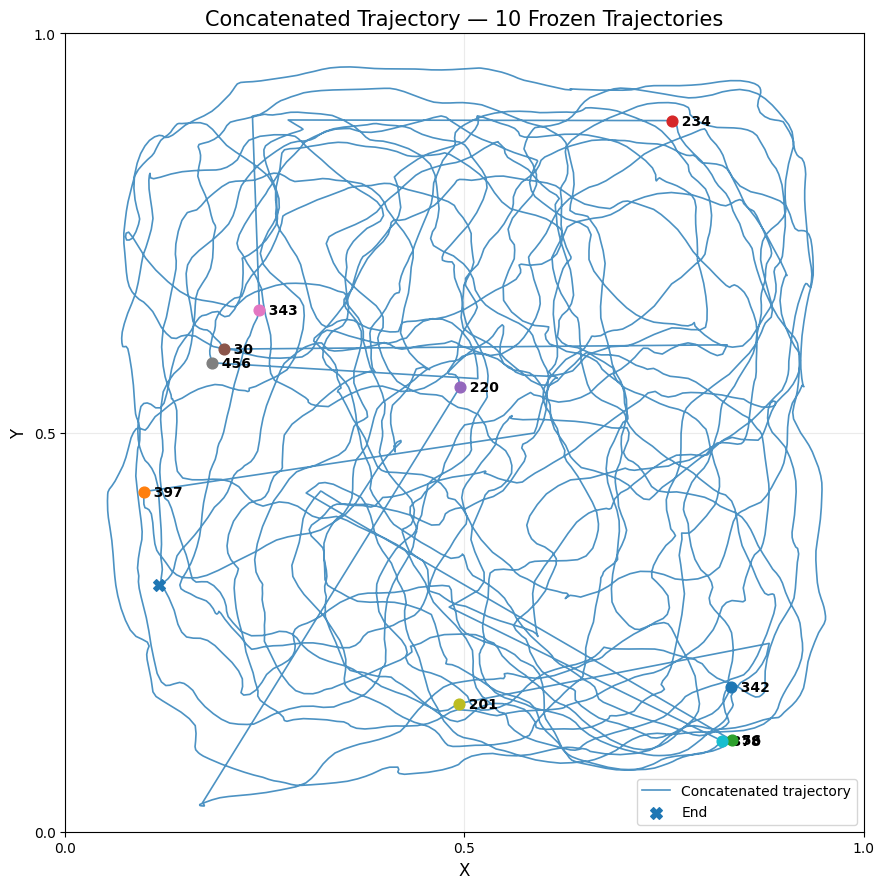

In [17]:
# ============================================================
# CONCATENATE + DISPLAY THE 10 FROZEN TRAJECTORIES
# ============================================================

# ------------------------------------------------------------
# 1. Concatenate positions
# ------------------------------------------------------------

combined_positions = np.concatenate(
    [
        positions[traj_id]
        for traj_id in selected_traj
    ],
    axis=0
)

print("Frozen trajectories:")
print(selected_traj)

print(
    "\nCombined trajectory shape:",
    combined_positions.shape
)


# ============================================================
# 2. Plot concatenated trajectory
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9)
)

# ------------------------------------------------------------
# Plot the complete concatenated trajectory
# ------------------------------------------------------------

ax.plot(
    combined_positions[:, 0],
    combined_positions[:, 1],
    linewidth=1.2,
    alpha=0.8,
    label="Concatenated trajectory"
)


# ============================================================
# 3. Mark where each original trajectory starts
# ============================================================

trajectory_length = positions.shape[1]

for i, traj_id in enumerate(
    selected_traj
):

    start_idx = (
        i * trajectory_length
    )

    start_position = (
        combined_positions[start_idx]
    )

    # Mark starting point
    ax.scatter(
        start_position[0],
        start_position[1],
        s=60,
        marker="o",
        zorder=5
    )

    # Label trajectory
    ax.text(
        start_position[0],
        start_position[1],
        f"  {traj_id}",
        fontsize=10,
        fontweight="bold",
        verticalalignment="center"
    )


# ============================================================
# 4. Mark final point
# ============================================================

ax.scatter(
    combined_positions[-1, 0],
    combined_positions[-1, 1],
    s=70,
    marker="X",
    zorder=6,
    label="End"
)


# ============================================================
# 5. Formatting
# ============================================================

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.set_aspect(
    "equal"
)

ax.set_xlabel(
    "X",
    fontsize=12
)

ax.set_ylabel(
    "Y",
    fontsize=12
)

ax.set_title(
    "Concatenated Trajectory — 10 Frozen Trajectories",
    fontsize=15
)

ax.set_xticks(
    [0, 0.5, 1]
)

ax.set_yticks(
    [0, 0.5, 1]
)

ax.grid(
    alpha=0.25
)

ax.legend(
    fontsize=10
)

plt.tight_layout()
plt.show()


Occupancy probability:
(40, 40)
Probability sum: 1.0

Combined rate maps:
(100, 40, 40)

SI shape:
(100,)

Sparsity shape:
(100,)

Common firing-rate vmax: 1069.860105940091


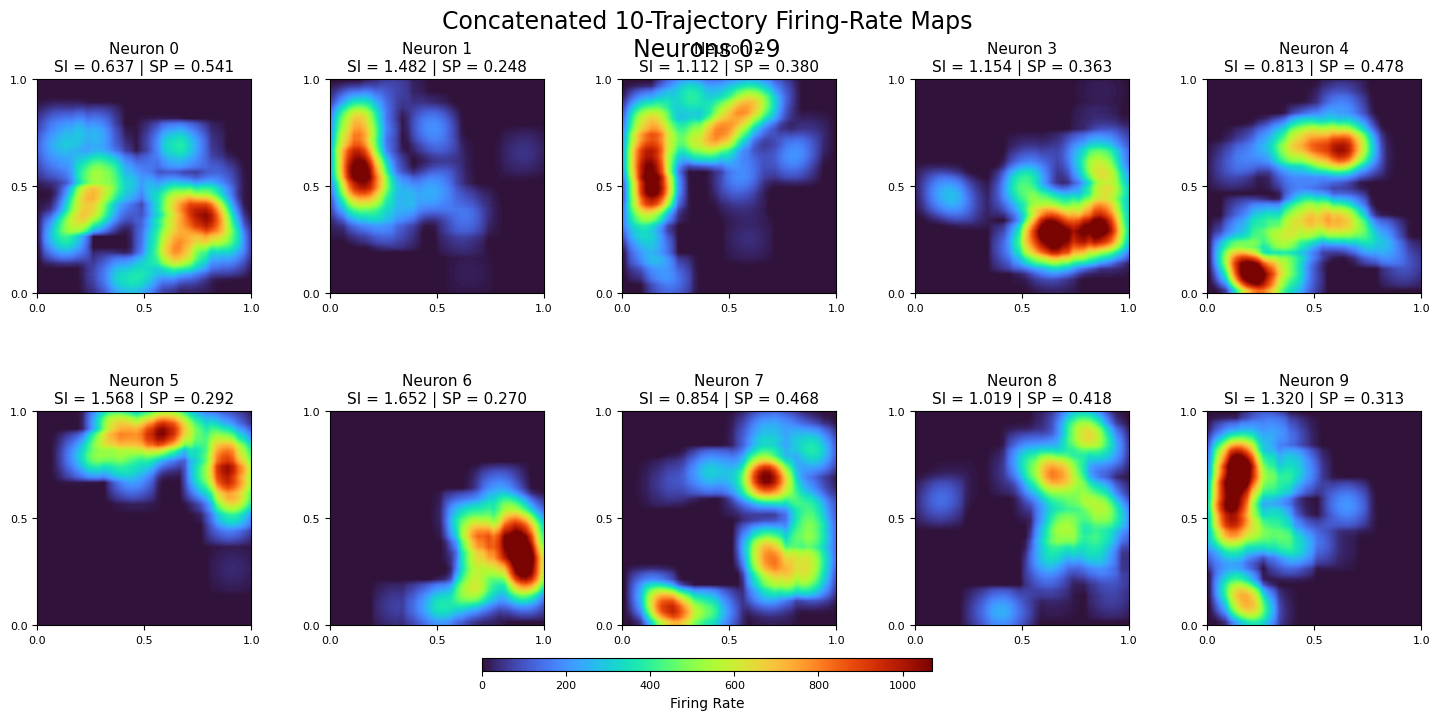

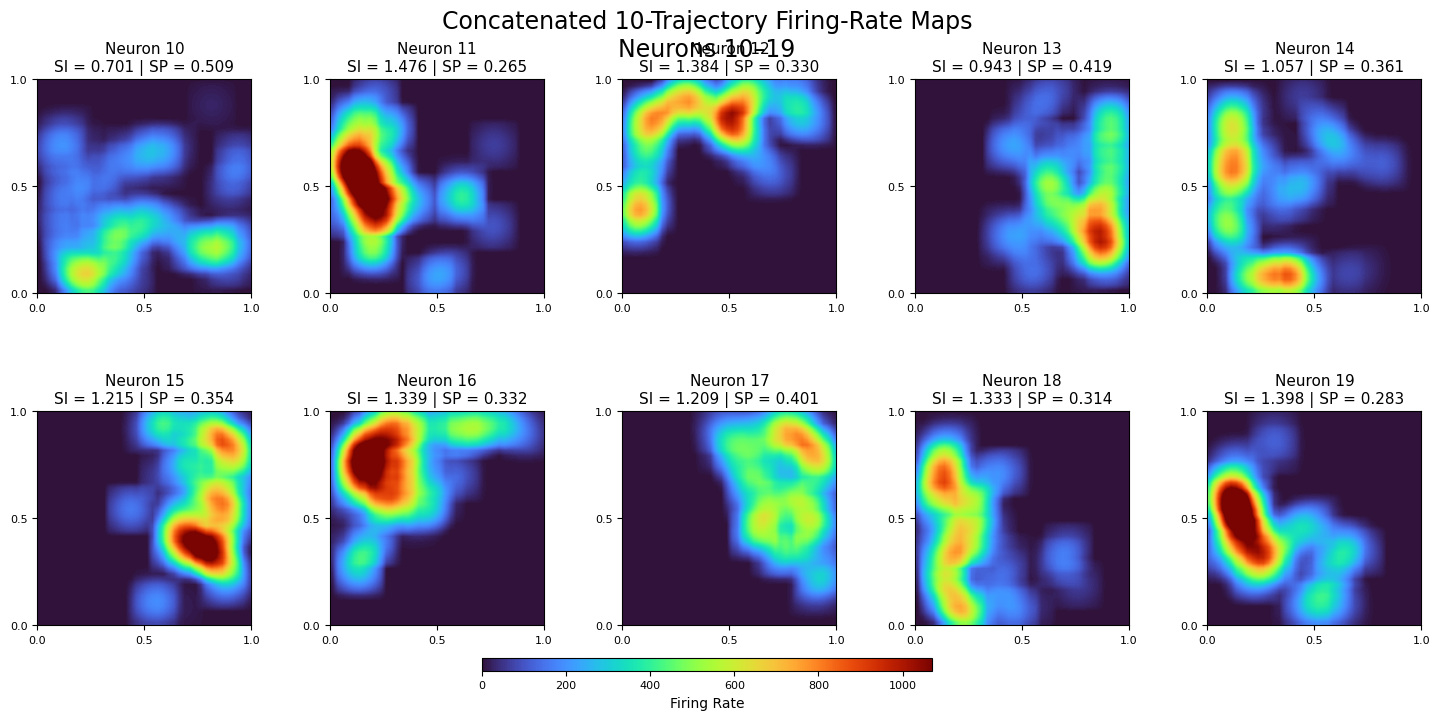

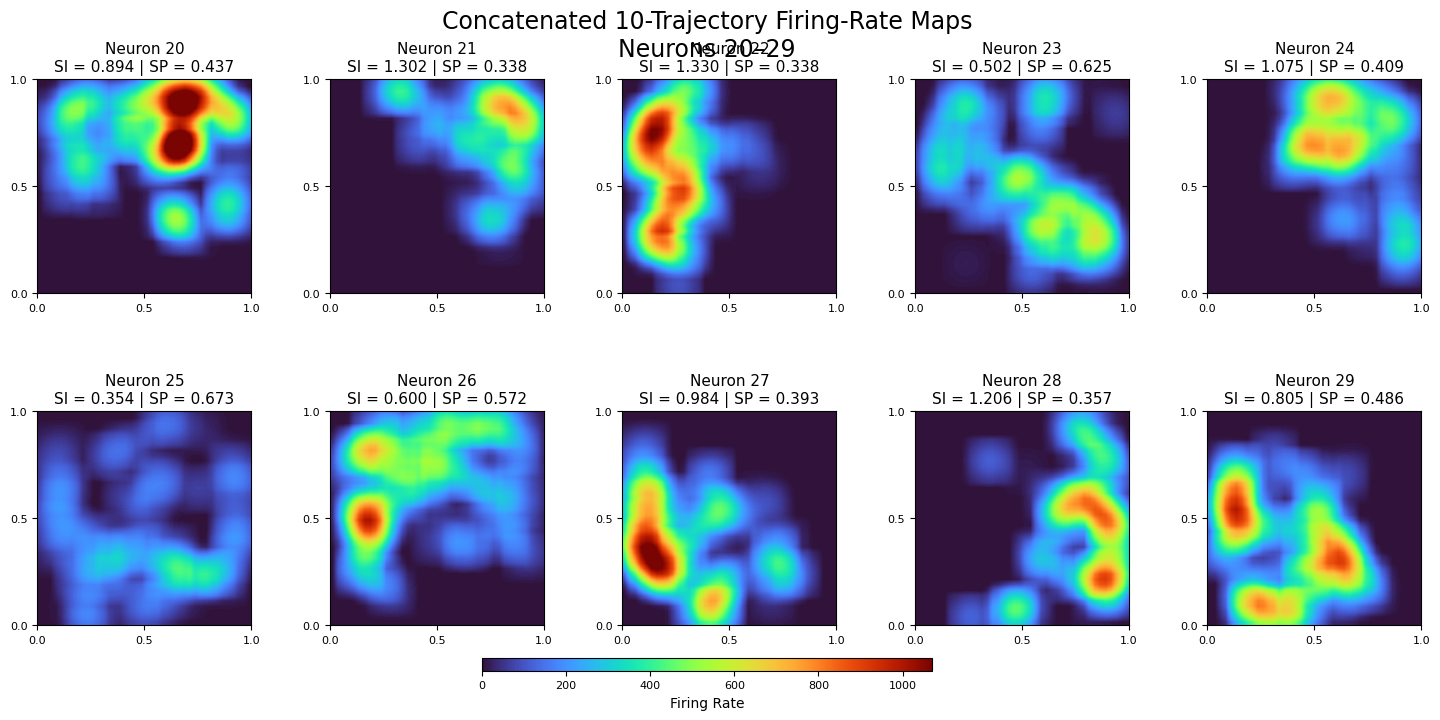

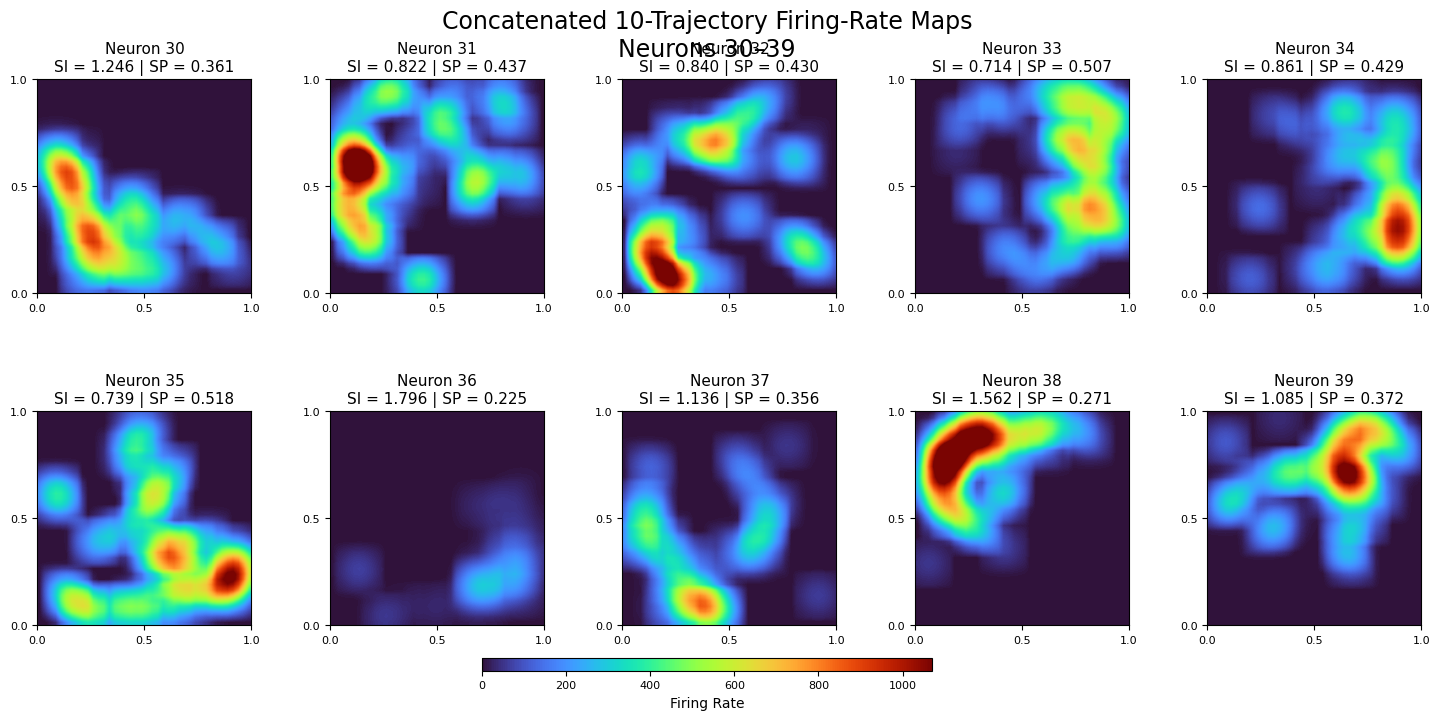

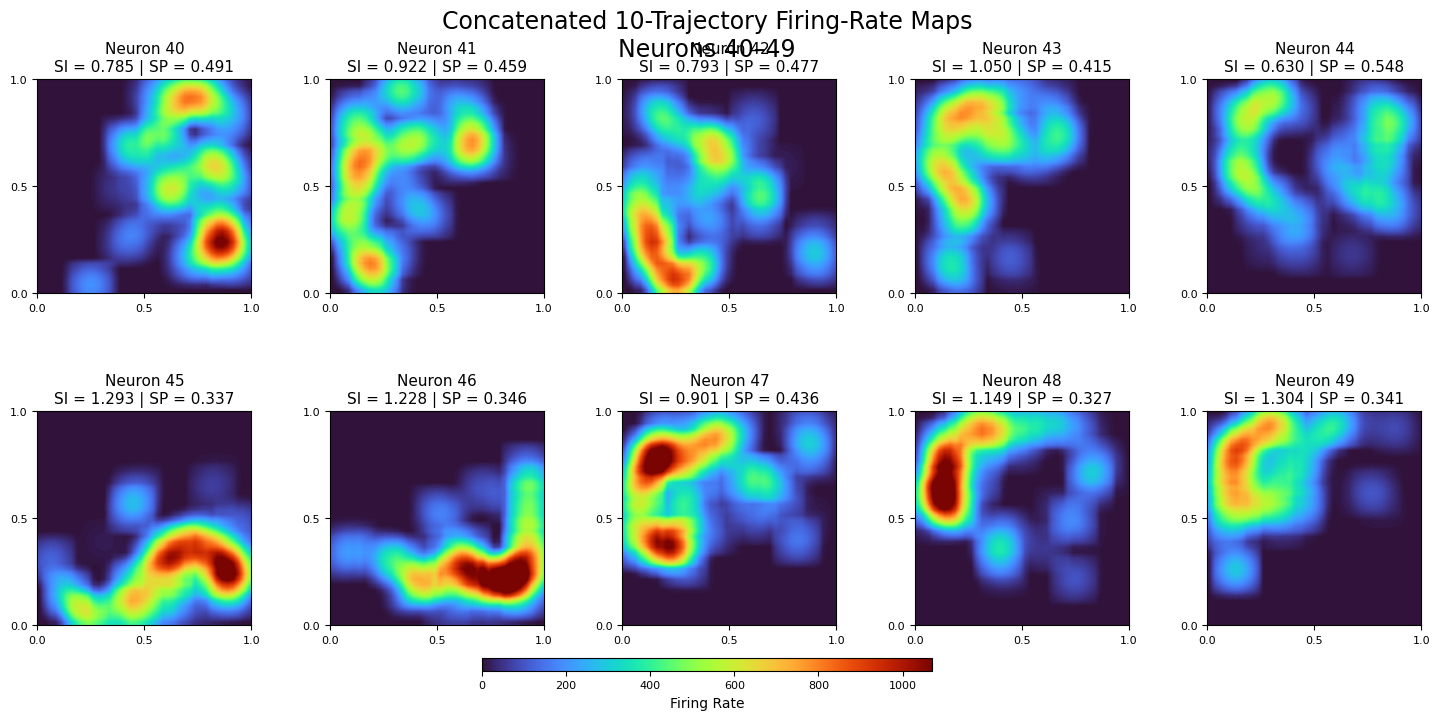

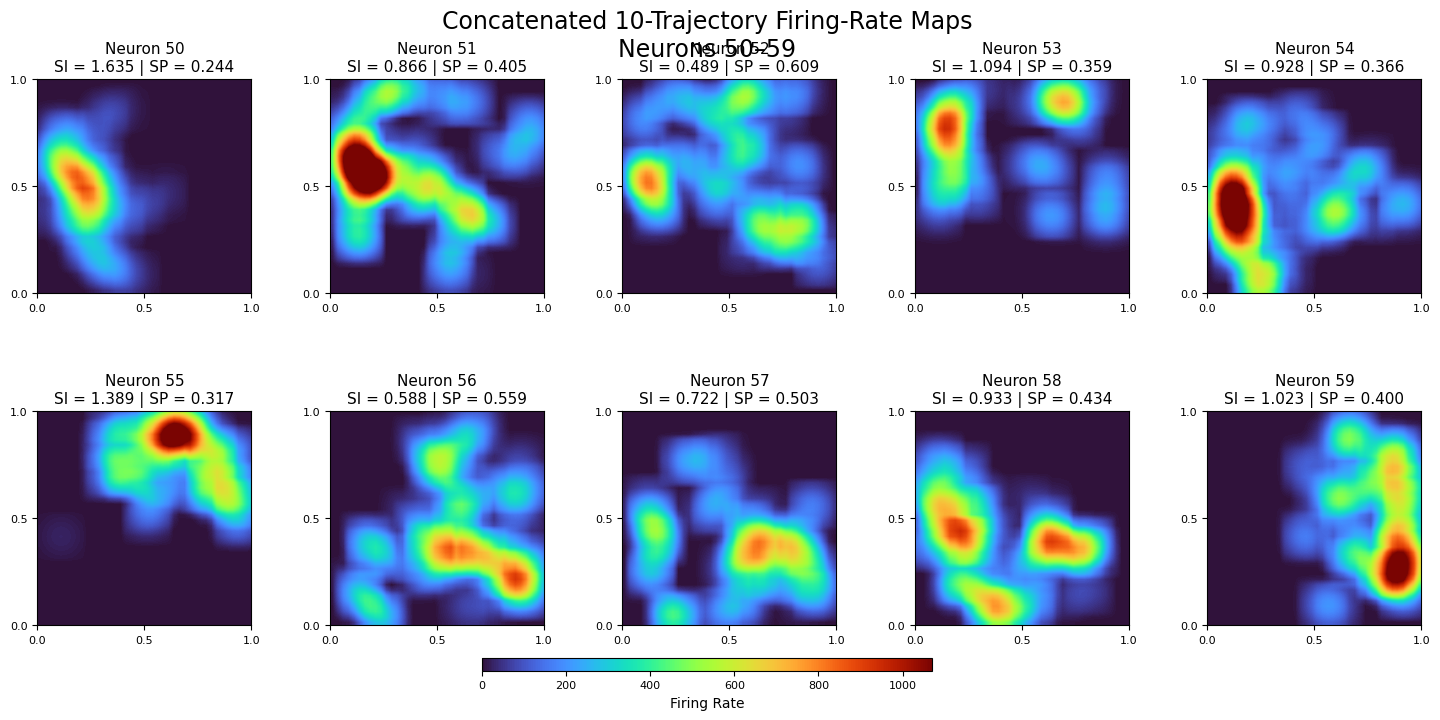

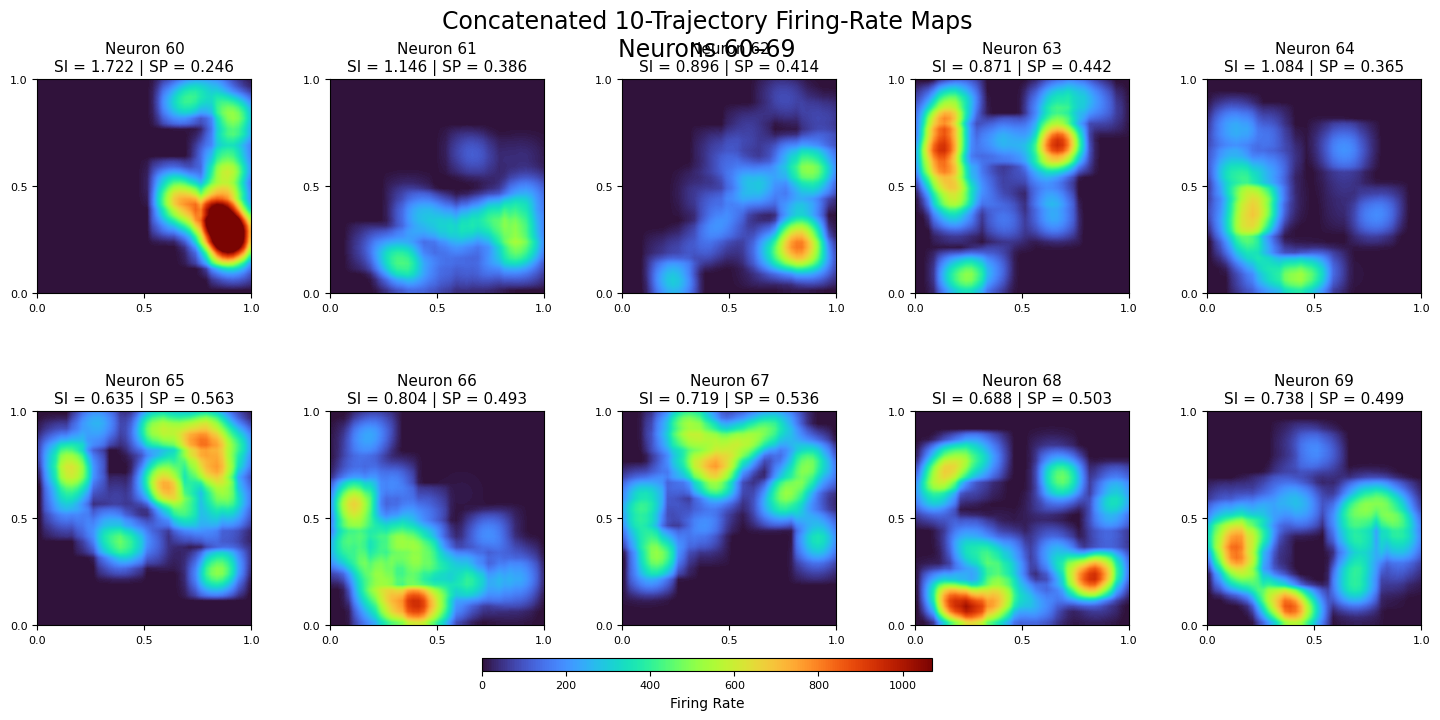

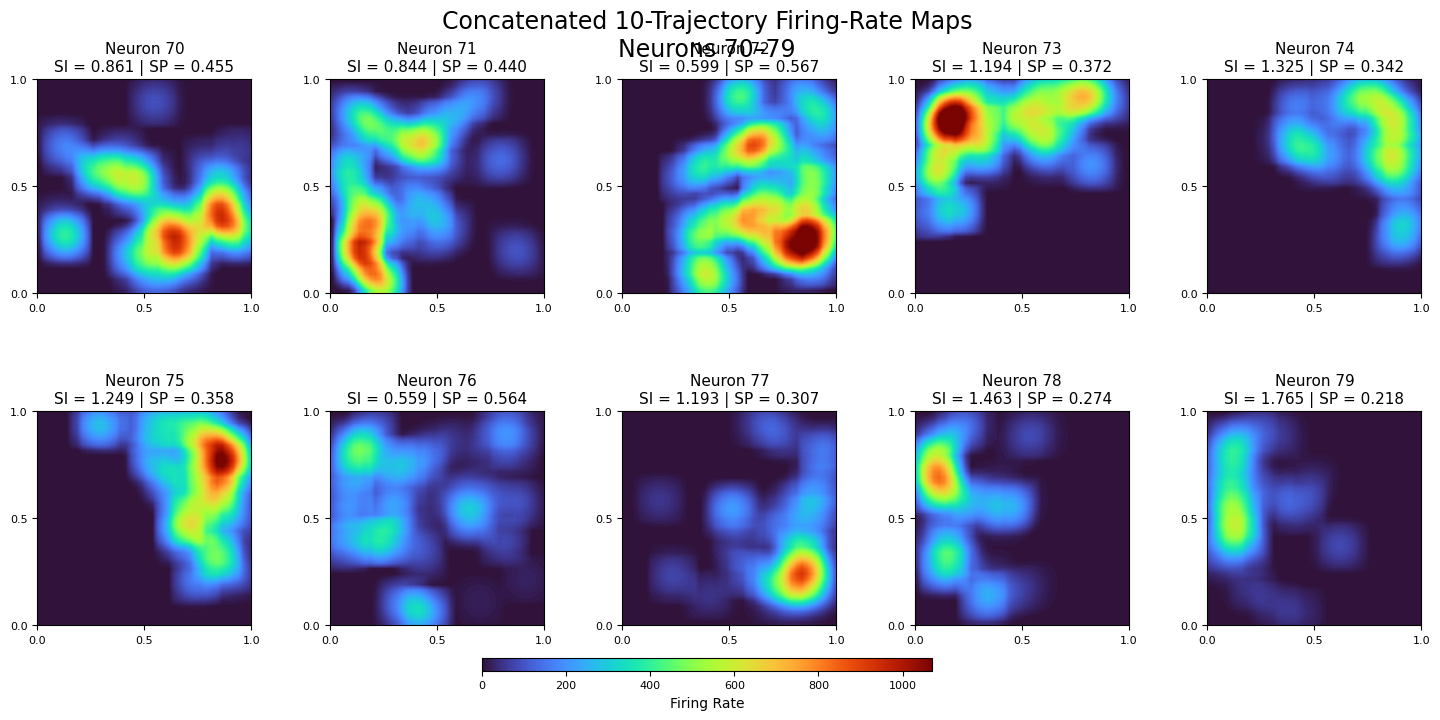

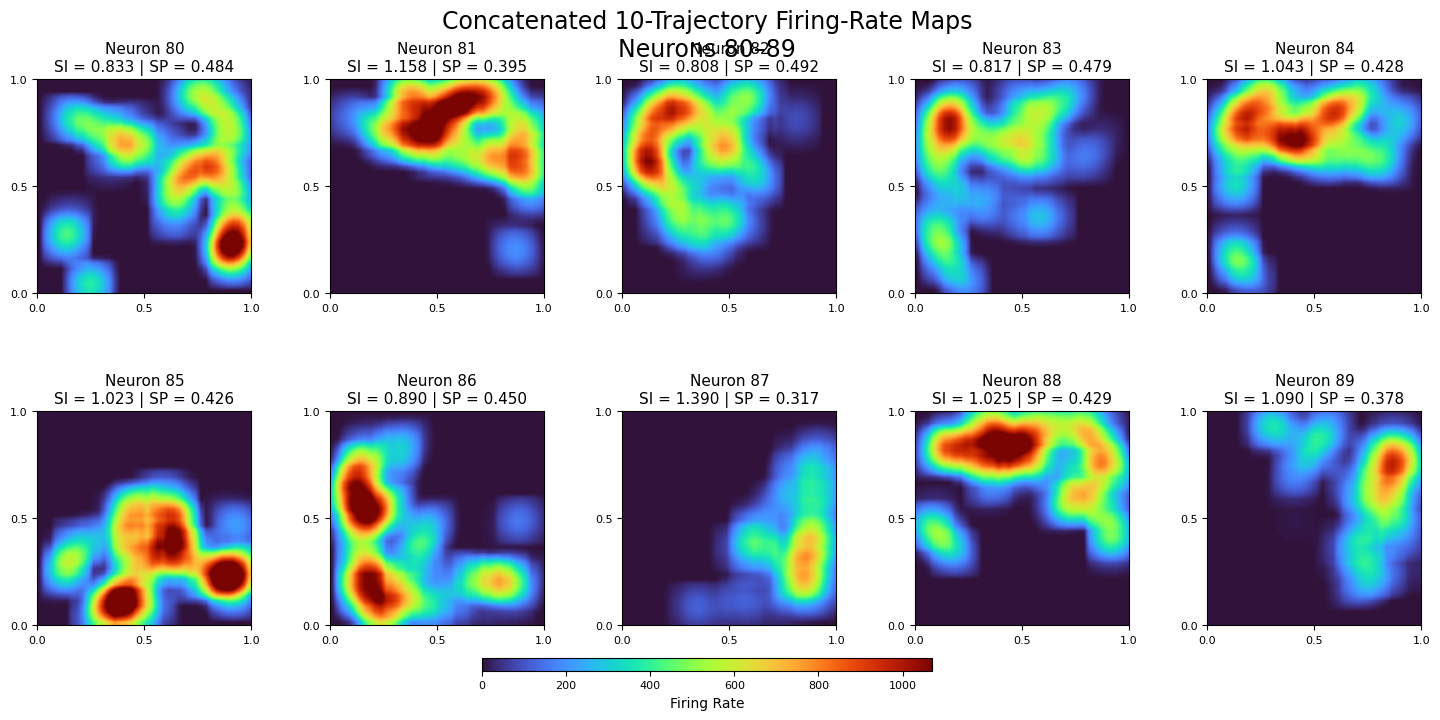

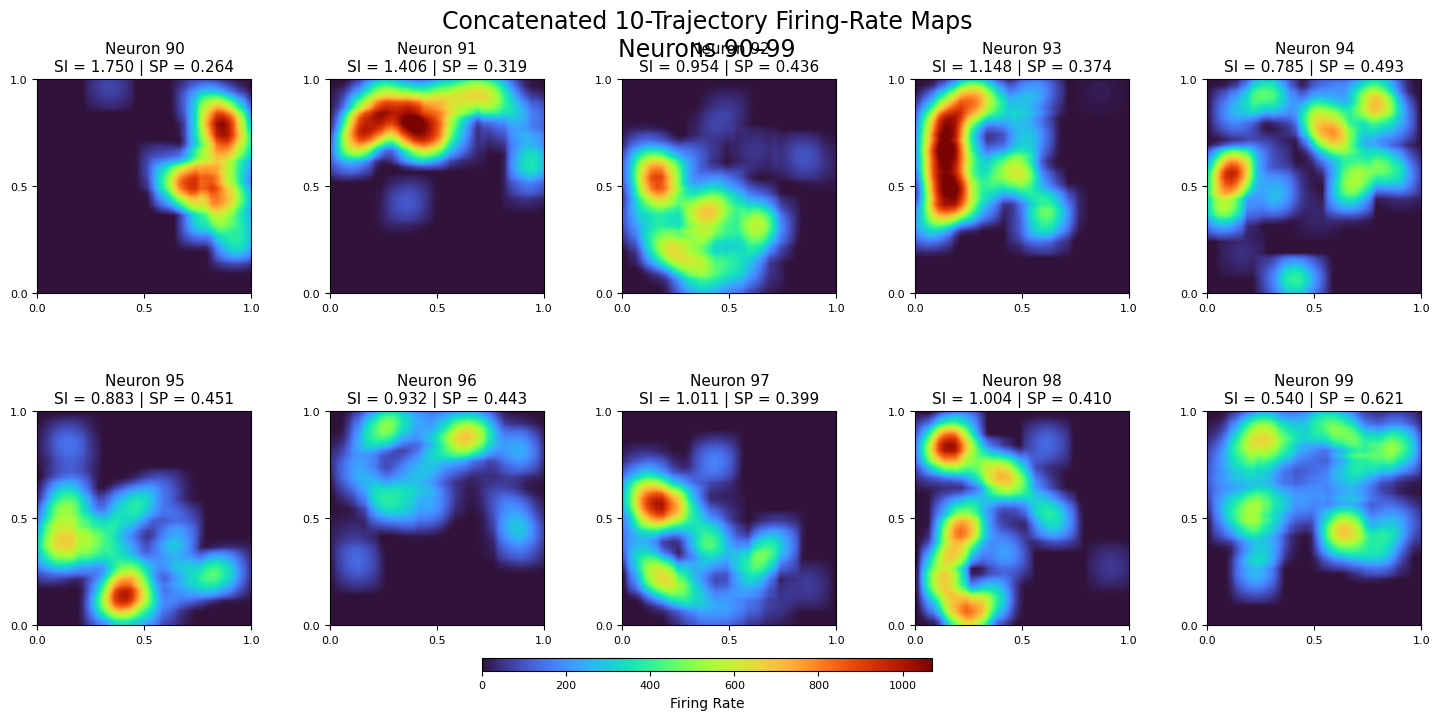


BEST RESULTS — CONCATENATED TRAJECTORIES
Highest SI       : Neuron 36 (1.796076)
Lowest Sparsity  : Neuron 79 (0.218213)


In [18]:
# ============================================================
# CONCATENATED 10-TRAJECTORY PLACE-CELL ANALYSIS
#
# The 10 frozen trajectories are concatenated into ONE
# continuous dataset, then the same pipeline is applied
# independently to all 100 neurons.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 2. COMBINED OCCUPANCY PROBABILITY
# ============================================================

combined_counts, _, _ = np.histogram2d(
    combined_positions[:, 0],
    combined_positions[:, 1],
    bins=[x_edges, y_edges]
)

total_samples = combined_counts.sum()

combined_occupancy_probability = (
    combined_counts / total_samples
)


print("\nOccupancy probability:")
print(
    combined_occupancy_probability.shape
)

print(
    "Probability sum:",
    combined_occupancy_probability.sum()
)


# ============================================================
# 3. CALCULATE FIRING-RATE MAPS
#    FOR ALL 100 NEURONS
# ============================================================

N_NEURONS = combined_activations.shape[1]

combined_rate_maps = np.full(
    (
        N_NEURONS,
        N_BINS,
        N_BINS
    ),
    np.nan
)


for neuron in range(N_NEURONS):

    responses = combined_activations[
        :,
        neuron
    ]

    combined_rate_maps[
        neuron
    ], _ = build_firing_rate_map(
        responses=responses,
        pos=combined_positions,
        occupancy_map=combined_occupancy_probability,
        thresh_param=THRESHOLD_K,
        res_param=N_BINS,
        gaussian_shape=(
            GAUSSIAN_WINDOW,
            GAUSSIAN_WINDOW
        ),
        gaussian_sigma=GAUSSIAN_SIGMA,
        normalization="occupancy"
    )


print(
    "\nCombined rate maps:"
)

print(
    combined_rate_maps.shape
)


# ============================================================
# 4. SPATIAL INFORMATION + SPARSITY
# ============================================================

combined_si = np.full(
    N_NEURONS,
    np.nan
)

combined_sparsity = np.full(
    N_NEURONS,
    np.nan
)


for neuron in range(N_NEURONS):

    rate_map = combined_rate_maps[
        neuron
    ]

    combined_si[
        neuron
    ] = spatial_information(
        rate_map,
        combined_occupancy_probability
    )

    combined_sparsity[
        neuron
    ] = sparsity(
        rate_map,
        combined_occupancy_probability
    )


print("\nSI shape:")
print(
    combined_si.shape
)

print("\nSparsity shape:")
print(
    combined_sparsity.shape
)


# ============================================================
# 5. FIND COMMON COLOR SCALE
# ============================================================

valid_rates = combined_rate_maps[
    np.isfinite(combined_rate_maps)
    &
    (combined_rate_maps > 0)
]


if len(valid_rates) > 0:

    combined_vmax = np.percentile(
        valid_rates,
        99
    )

else:

    combined_vmax = 1.0


print(
    "\nCommon firing-rate vmax:",
    combined_vmax
)


# ============================================================
# 6. DISPLAY 100 NEURONS
#
#    10 FIGURES
#    10 NEURONS PER FIGURE
# ============================================================

NEURONS_PER_FIGURE = 10

N_FIGURES = int(
    np.ceil(
        N_NEURONS
        / NEURONS_PER_FIGURE
    )
)


for figure_number in range(
    N_FIGURES
):

    start = (
        figure_number
        * NEURONS_PER_FIGURE
    )

    end = min(
        start + NEURONS_PER_FIGURE,
        N_NEURONS
    )

    figure_neurons = list(
        range(start, end)
    )


    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(15, 7)
    )

    axes = axes.ravel()


    # --------------------------------------------------------
    # Plot neurons
    # --------------------------------------------------------

    im = None

    for plot_index, neuron in enumerate(
        figure_neurons
    ):

        ax = axes[
            plot_index
        ]

        rate_map = combined_rate_maps[
            neuron
        ].copy()

        rate_map = np.nan_to_num(
            rate_map,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )


        im = ax.imshow(
            rate_map.T,
            origin="lower",
            extent=[
                0,
                1,
                0,
                1
            ],
            cmap="turbo",
            aspect="equal",
            interpolation="bilinear",
            vmin=0,
            vmax=combined_vmax
        )


        # ----------------------------------------------------
        # SI + sparsity
        # ----------------------------------------------------

        si = combined_si[
            neuron
        ]

        sp = combined_sparsity[
            neuron
        ]


        ax.set_title(
            (
                f"Neuron {neuron}\n"
                f"SI = {si:.3f} | "
                f"SP = {sp:.3f}"
            ),
            fontsize=11
        )


        ax.set_xlim(
            0,
            1
        )

        ax.set_ylim(
            0,
            1
        )

        ax.set_xticks(
            [0, 0.5, 1]
        )

        ax.set_yticks(
            [0, 0.5, 1]
        )

        ax.tick_params(
            labelsize=8
        )


    # --------------------------------------------------------
    # Hide unused axes
    # --------------------------------------------------------

    for plot_index in range(
        len(figure_neurons),
        10
    ):

        axes[
            plot_index
        ].axis("off")


    # ========================================================
    # TITLE
    # ========================================================

    first_neuron = figure_neurons[0]
    last_neuron = figure_neurons[-1]

    fig.suptitle(
        (
            "Concatenated 10-Trajectory Firing-Rate Maps\n"
            f"Neurons {first_neuron}–{last_neuron}"
        ),
        fontsize=17,
        y=0.98
    )


    # ========================================================
    # COLORBAR
    # ========================================================

    cbar_ax = fig.add_axes(
        [
            0.35,
            0.035,
            0.30,
            0.018
        ]
    )


    cbar = fig.colorbar(
        im,
        cax=cbar_ax,
        orientation="horizontal"
    )

    cbar.set_label(
        "Firing Rate",
        fontsize=10
    )

    cbar.ax.tick_params(
        labelsize=8
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    plt.subplots_adjust(
        left=0.05,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.30,
        hspace=0.55
    )

    plt.show()


# ============================================================
# 7. FINAL RANKING
# ============================================================

best_si_neuron = np.nanargmax(
    combined_si
)

lowest_sparsity_neuron = np.nanargmin(
    combined_sparsity
)


print("\n" + "=" * 60)
print("BEST RESULTS — CONCATENATED TRAJECTORIES")
print("=" * 60)

print(
    f"Highest SI       : "
    f"Neuron {best_si_neuron} "
    f"({combined_si[best_si_neuron]:.6f})"
)

print(
    f"Lowest Sparsity  : "
    f"Neuron {lowest_sparsity_neuron} "
    f"({combined_sparsity[lowest_sparsity_neuron]:.6f})"
)